# Lab — Time Series Analysis with the UCI Bike Sharing Dataset

**Module:** Time Series Analysis and Forecasting  
**Estimated Time:** 90–120 minutes  
**Dataset:** UCI Bike Sharing Dataset, `day.csv`  
**Primary Skills:** datetime handling, time series data quality, resampling, rolling averages, seasonality analysis, baseline forecasting, forecast evaluation

---

## Lab Scenario

You are a data analyst for a bike sharing company.

Your manager wants to understand how bike rental demand changes over time and whether simple baseline forecasts can provide a useful starting point for short-term demand planning.

Before building any advanced forecasting model, your job is to complete a practical time series workflow:

1. Load and inspect the dataset.
2. Convert the date column into a proper datetime format.
3. Sort and index the data chronologically.
4. Check whether the time series has missing dates or duplicate timestamps.
5. Explore trend, seasonality, and rolling averages.
6. Build simple baseline forecasts.
7. Evaluate the forecasts with MAE and RMSE.
8. Communicate your findings clearly.

This lab is intentionally focused on workflow and interpretation, not advanced forecasting models.

---

## Dataset Overview

You will use the **UCI Bike Sharing Dataset**.

For this lab, use the file:

```text
day.csv
```

Each row represents one day of bike rental activity.

### Important Columns

| Column | Description |
|---|---|
| `instant` | Record index |
| `dteday` | Date |
| `season` | Season encoded as a number |
| `yr` | Year encoded as `0` or `1` |
| `mnth` | Month number |
| `holiday` | Whether the day was a holiday |
| `weekday` | Day of the week |
| `workingday` | Whether the day was a working day |
| `weathersit` | Weather situation category |
| `temp` | Normalized temperature |
| `atemp` | Normalized feeling temperature |
| `hum` | Normalized humidity |
| `windspeed` | Normalized wind speed |
| `casual` | Count of casual users |
| `registered` | Count of registered users |
| `cnt` | Total rental bike count |

For this lab, your main target column is:

```python
cnt
```

This represents total bike rentals for the day.

---

## Lab Learning Objectives

By the end of this lab, you will be able to:

- Load a real time series dataset into pandas.
- Convert a date column using `pd.to_datetime()`.
- Sort a dataset chronologically.
- Set a datetime column as the DataFrame index.
- Check for duplicate timestamps.
- Check for missing dates in a daily time series.
- Resample daily data into weekly and monthly summaries.
- Use rolling averages to smooth noisy daily data.
- Analyze trend and seasonality.
- Create simple baseline forecasts.
- Evaluate forecasts using MAE and RMSE.
- Explain the limitations of baseline forecasting.

---

---

## Part 1 — Load the Dataset

### Option A: Load from a Local CSV File

Use this option if `day.csv` is already saved in your project folder.

```python
bike = pd.read_csv("day.csv")
```

### Option B: Load Directly from a URL

Use this option if your instructor gives you a direct raw CSV URL.

```python
url = "YOUR_RAW_CSV_URL_HERE"
bike = pd.read_csv(url)
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

I was a biy confused with the different options I am just used to using path 

In [2]:
BIKE_URL = Path("..") / "data" / "raw" / "day.csv"

In [3]:
url = BIKE_URL

In [4]:
bike = pd.read_csv(url)

In [5]:
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [6]:
bike.shape

(731, 16)

In [7]:
bike.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


---
### Questions

Answer these in a markdown cell:

1. How many rows are in the dataset?
2. What does one row represent?
3. Which column contains the date?
4. Which column contains the total number of rentals?
5. Is the date column already stored as a datetime type?


1.There are 731 rows in teh datyset with 16 columns 
2. One row repsents one day 
3.The column that contains the date is dteday 
4.The column that contains the total amount of rentals is cnt
5. No teh dteday is currently saved as a object we will have TO FIX THAT 

---

## Part 2 — Create a Proper Datetime Index

The column `dteday` contains the date, but pandas may initially read it as text.

### Tasks:

1. Convert `dteday` to Datetime

2. Sort by Date

3. Set the Date as the Index

### Questions

Answer these in a markdown cell:

1. Why do we convert `dteday` with `pd.to_datetime()`?
2. Why should time series data be sorted before analysis?
3. What changed after setting `dteday` as the index?


In [9]:
bike["dteday"] = pd.to_datetime(bike["dteday"])

In [10]:
bike["dteday"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 731 entries, 0 to 730
Series name: dteday
Non-Null Count  Dtype         
--------------  -----         
731 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 5.8 KB


In [11]:
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [12]:
bike = bike.sort_values("dteday").reset_index(drop=True)
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [13]:
bike_ts = bike.set_index("dteday")

bike_ts.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
bike_ts.index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2012-12-22', '2012-12-23', '2012-12-24', '2012-12-25',
               '2012-12-26', '2012-12-27', '2012-12-28', '2012-12-29',
               '2012-12-30', '2012-12-31'],
              dtype='datetime64[ns]', name='dteday', length=731, freq=None)

1 We convert this column dteday with an object thing call pd.to_datetime() becasue as humans we interpret time linearly
so if we make time series graphs we can understand them thats why the first thing we do is to make sure the data is good and usable 
in this example we can now work with time series data python now knows that the data type is a datetime variable type when we make grapsh and compare moving averages we can show changes over time 
3. When we set the the date as the index we ensure we order it in chronological order setting the date as first indexed column so we can easily 
recognize teh differences 

---

## Part 3 — Time Series Data Quality Checks

Before analyzing a time series, check whether the time index is complete, unique, sorted, and regular.

### Tasks 

1. Check for Duplicate Timestamps
2. Check Whether the Index Is Sorted
3. Infer the Frequency
4. Check for Missing Dates

### Questions

Answer these in a markdown cell:

1. Are there duplicate dates?
2. Is the index sorted chronologically?
3. Does pandas detect a daily frequency?
4. Are any dates missing?
5. Why are missing timestamps different from missing values?


In [15]:
# checks for duplicated rows 
bike_ts.index.duplicated().sum()

np.int64(0)

In [16]:
# checks for chronological order 
bike_ts.index.is_monotonic_increasing

True

In [17]:
# checking the frequncy of updating D = days
bike_ts.index.inferred_freq

'D'

In [18]:
#checking for missing days 
expected_days = pd.date_range(


    start=bike_ts.index.min(),
    end=bike_ts.index.max(),
    freq='D'
)

In [19]:
# checking the days expected versus teh days missing 
missing_days = expected_days.difference(bike_ts.index)
missing_days

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [20]:
#all good here we have no missing days in the given date range 

1.In this case there are no duplicated dates 
2. The index is sorted chronologically 
3.Yes pandas detycts a daily update frequency 
4.There are no dates missing
5.No we are not missing timestamps for missing values

## Part 4 — Initial Time Series Visualization

### Tasks 

1. Plot Daily Bike Rentals

### Questions

Answer these in a markdown cell:

1. Does bike rental demand appear to change over time?
2. Do you notice any repeating patterns?
3. Does the data look noisy at the daily level?
4. Are there any sudden drops or spikes worth investigating?

---


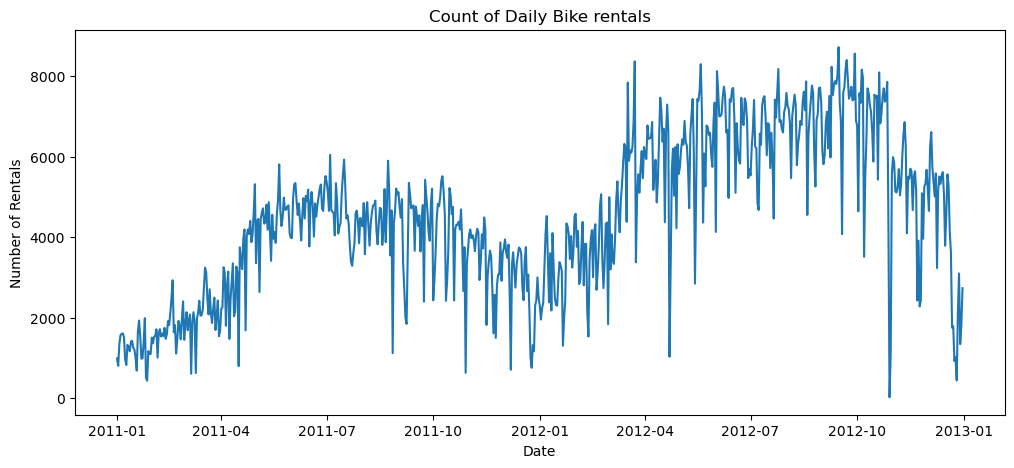

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(bike_ts["cnt"])
plt.title("Count of Daily Bike rentals")
plt.xlabel("Date")
plt.ylabel("Number of Rentals");


1. Bike Demand doesa seems to change overtime 

2. There does seem to be be soem seasonality it seems a peak during spring summer and fall months and then as it gets colder it tapers off
3. Teh data does look a bit noisy it is difficult to read
4. There are sudden drops a question is could they be holidaysd were peopel may be less likely to rent a bike ?

## Part 5 — Resampling Daily Data

Daily data can be noisy. Resampling helps summarize the data at a different time level.

### Tasks 

1. Weekly Total Rentals
2. Monthly Total Rentals
3. Monthly Average Daily Rentals

### Questions

Answer these in a markdown cell:

1. What question does weekly total rentals answer?
2. What question does monthly total rentals answer?
3. What question does monthly average daily rentals answer?
4. How does resampling change what you can see in the data?
5. Which version is easier to interpret: daily, weekly, or monthly? Why?

---

1. The question that weekly trotal rentals answers is how mnay rentals were there totaly in the past 7 days
2. Monthly total tells us how many rental there were in a month
3. Daily Average Renatls is the  average rentals you could expect daily for that month
4. Resampling removes nouise from the data and allows us to see genreal  trends without the pull of certain outliers
5. I think that monlt total and monthly average remove enough noise fropm the data where it is easier to see teh trends of that montly and daily averages more clearly 

In [27]:
#Resample monthly to yearly count 
weekly_total = bike_ts["cnt"].resample("W").sum()

In [28]:
monthly_total = bike_ts["cnt"].resample("ME").sum()

In [29]:
monthly_avg = bike_ts["cnt"].resample("ME").mean()

In [30]:
print("--- WEEKLY TOTALS ---")
print(weekly_total.head())

--- WEEKLY TOTALS ---
dteday
2011-01-02    1786
2011-01-09    9408
2011-01-16    9025
2011-01-23    8770
2011-01-30    7699
Freq: W-SUN, Name: cnt, dtype: int64


In [31]:
print("\n--- MONTHLY TOTALS ---")
print(monthly_total.head())


--- MONTHLY TOTALS ---
dteday
2011-01-31     38189
2011-02-28     48215
2011-03-31     64045
2011-04-30     94870
2011-05-31    135821
Freq: ME, Name: cnt, dtype: int64


In [32]:
print("\n--- MONTHLY DAILY AVERAGES ---")
print(monthly_avg.head())


--- MONTHLY DAILY AVERAGES ---
dteday
2011-01-31    1231.903226
2011-02-28    1721.964286
2011-03-31    2065.967742
2011-04-30    3162.333333
2011-05-31    4381.322581
Freq: ME, Name: cnt, dtype: float64


cnt_summary = pd.DataFrame({

    "monthly_total_cnt":monthly_total,
    "monthly_avg_cnt":monthly_avg,
    "weekly_total_cnt":weekly_total,
                              
})

In [37]:
yearly_summary = pd.DataFrame({
    "monthly_cnt_sum":monthly_total,
    "monthly_cnt_avg":monthly_avg
})
    

In [43]:
yearly_summary.head()

,monthly_cnt_sum,monthly_cnt_avg
dteday,,
2011-01-31,38189,1231.903226
2011-02-28,48215,1721.964286
2011-03-31,64045,2065.967742
2011-04-30,94870,3162.333333
2011-05-31,135821,4381.322581


<Axes: xlabel='dteday'>

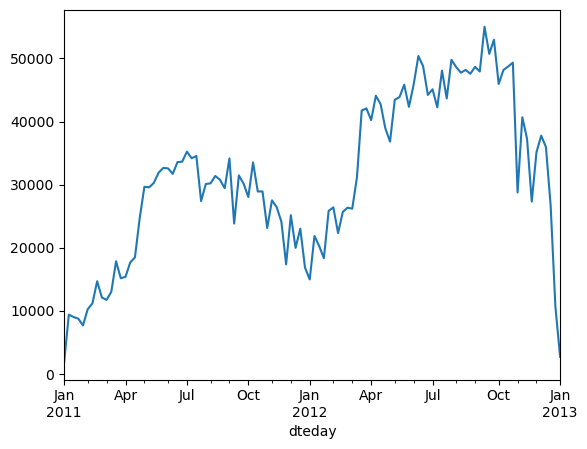

In [33]:
weekly_total.plot()

<Axes: xlabel='dteday'>

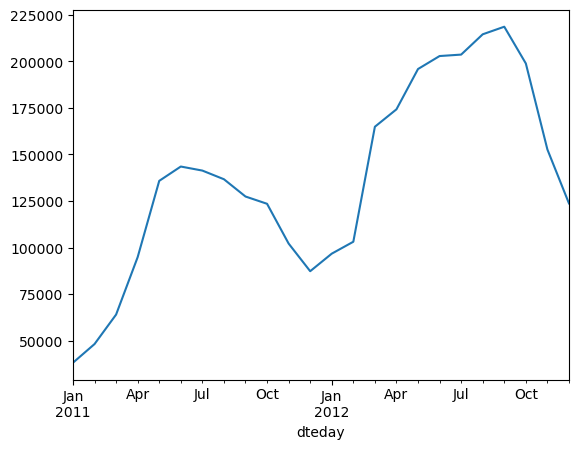

In [34]:
monthly_total.plot()

<Axes: xlabel='dteday'>

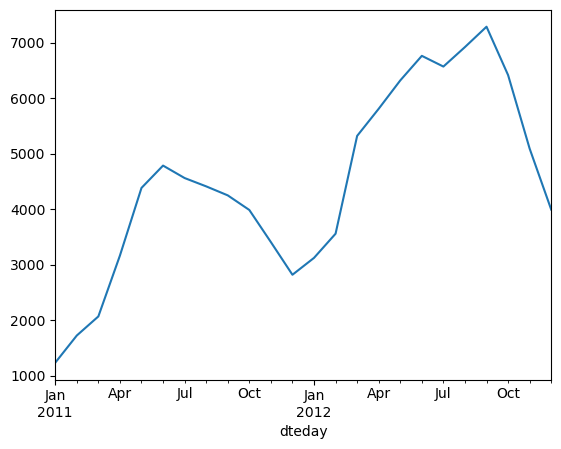

In [35]:
monthly_avg.plot()

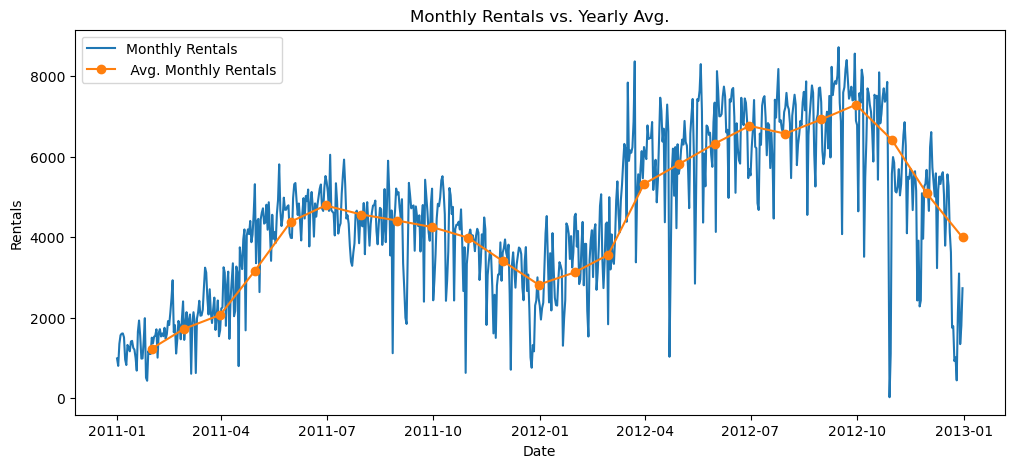

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(bike_ts["cnt"], label='Monthly Rentals')
plt.plot(monthly_avg, marker='o', label=" Avg. Monthly Rentals")
plt.title("Monthly Rentals vs. Yearly Avg.")
plt.xlabel("Date")
plt.ylabel("Rentals")
plt.legend();

---
## Part 6 — Rolling Averages

Rolling averages help smooth short-term fluctuations.

### Tasks 

1. Create Rolling Average Columns for 7 and 30 days
2. Plot Daily Rentals with Rolling Averages

### Questions

Answer these in a markdown cell:

1. What does the 7-day rolling average smooth out?
2. What does the 30-day rolling average reveal?
3. Which line is most useful for seeing short-term changes?
4. Which line is most useful for seeing the larger trend?
5. Why do the first few rolling average values appear as missing?

---

1.The 7 day mosing average smooths out teh daily incosnistancies 
2. the 30-day moving avergae smoothes out teh data even more 
3. I would say the teh 7 days offers better insight from week to week changes and you can adapt quicker to change and your are resisnat to the mean changing if there is oneday of stagnation 
4. The 30 day rolling average is better for seeing the larger trend at hand, it smoothes teh graph over and makes it a lot legible from a daily perscpetive
5. the first few average values appear missing because 7 dayd or 30 days  have to mast to have an average of t hat in teh first place 


 plot the full time series
 1.plt.figure(figsize=(12, 5))
2.plt.plot(passengers_ts["passengers"])
plt.title("Monthly Airline Passengers over time")
plt.xlabel("Date")
plt.ylabel("Passengers");

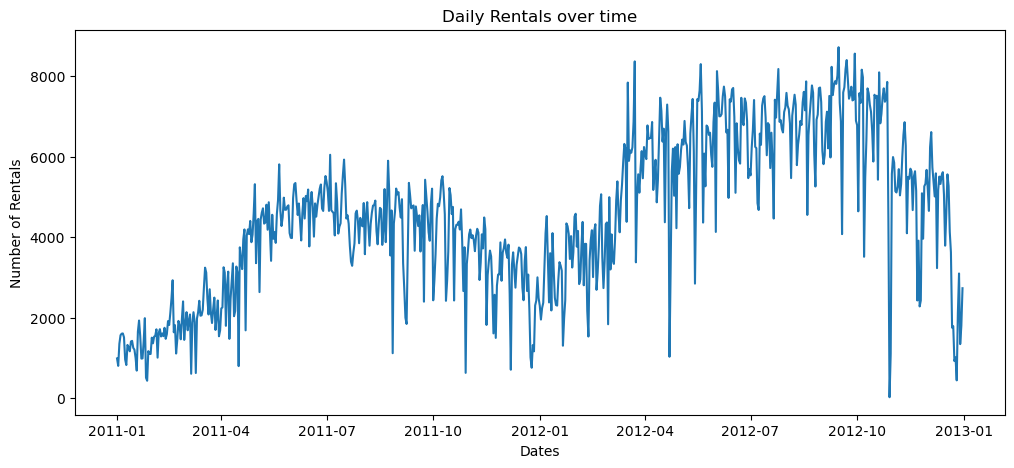

In [54]:
plt.figure(figsize=(12,5))
plt.plot(bike_ts["cnt"])
plt.title("Daily Rentals over time")
plt.xlabel("Dates")
plt.ylabel("Number of Rentals");

In [55]:
# ADD A 7 DAY ROLLING AVG
bike_ts["rolling_7_day_avg"] = bike_ts["cnt"].rolling(window=7).mean()

#30 day rolling avg 

bike_ts["rolling_30_day_avg"] = bike_ts["cnt"].rolling(window=30).mean()

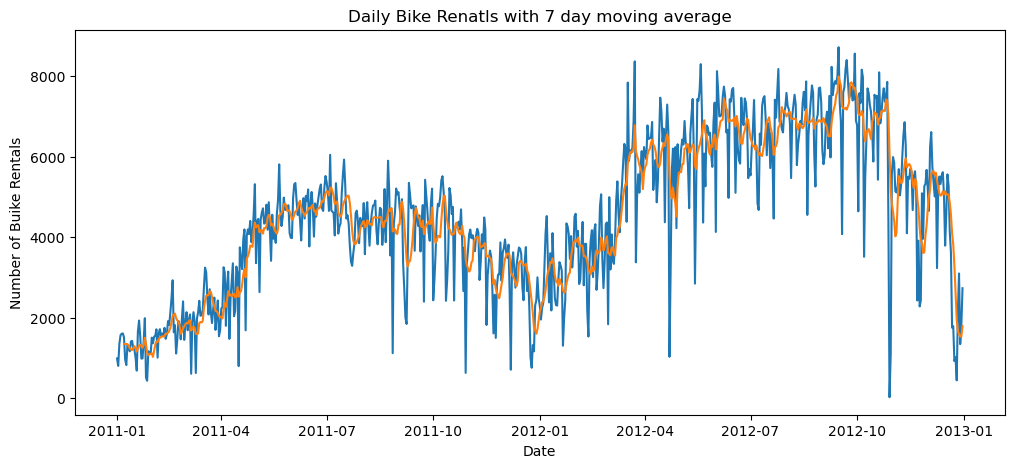

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(bike_ts["cnt"], label='Daily bike Rentals')
plt.plot(bike_ts["rolling_7_day_avg"], label="7 Day Rolling Avg")
plt.title("Daily Bike Renatls with 7 day moving average")
plt.xlabel("Date")
plt.ylabel("Number of Buike Rentals");

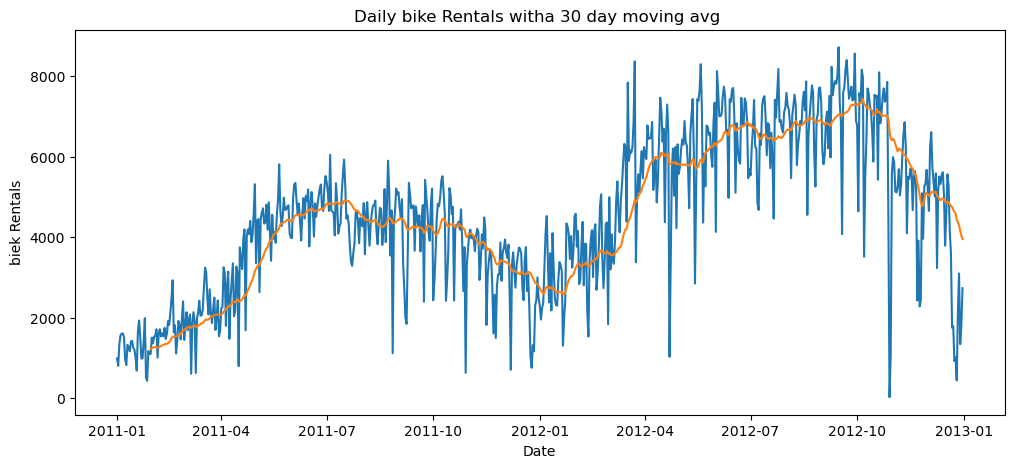

In [71]:
plt.figure(figsize=(12, 5))
plt.plot(bike_ts["cnt"], label='Daily Bike rentals')
plt.plot(bike_ts["rolling_30_day_avg"], label="30 Day moving average")
plt.title("Daily bike Rentals witha 30 day moving avg ")
plt.xlabel("Date")
plt.ylabel("biek Rentals");

---

## Part 7 — Date Part Features

Extracting date parts helps us analyze calendar-based patterns.

### Tasks 

1. Create Date Part Columns (Year, Month, Day, etc.)



In [64]:
bike_features = bike_ts.copy()

In [67]:
bike_features.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,rolling_7_day_avg,rolling_30_day_avg
dteday,,,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,NaN,NaN
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,NaN,NaN
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,NaN,NaN
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,NaN,NaN
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,NaN,NaN


In [68]:
bike_features["year"] = bike_features.index.year
bike_features["month"] = bike_features.index.month_name()
bike_features["month_number"] = bike_features.index.month
bike_features["quarter"] = bike_features.index.quarter

In [69]:
bike_features.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,...,windspeed,casual,registered,cnt,rolling_7_day_avg,rolling_30_day_avg,year,month,month_number,quarter
dteday,,,,,,,,,,,,,,,,,,,,,
2011-01-01,1,1,0,1,0,6,0,2,0.344167,0.363625,...,0.160446,331,654,985,NaN,NaN,2011,January,1,1
2011-01-02,2,1,0,1,0,0,0,2,0.363478,0.353739,...,0.248539,131,670,801,NaN,NaN,2011,January,1,1
2011-01-03,3,1,0,1,0,1,1,1,0.196364,0.189405,...,0.248309,120,1229,1349,NaN,NaN,2011,January,1,1
2011-01-04,4,1,0,1,0,2,1,1,0.200000,0.212122,...,0.160296,108,1454,1562,NaN,NaN,2011,January,1,1
2011-01-05,5,1,0,1,0,3,1,1,0.226957,0.229270,...,0.186900,82,1518,1600,NaN,NaN,2011,January,1,1


In [70]:
bike_features.tail()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,...,windspeed,casual,registered,cnt,rolling_7_day_avg,rolling_30_day_avg,year,month,month_number,quarter
dteday,,,,,,,,,,,,,,,,,,,,,
2012-12-27,727,1,1,12,0,4,1,2,0.254167,0.226642,...,0.350133,247,1867,2114,1663.857143,4366.766667,2012,December,12,4
2012-12-28,728,1,1,12,0,5,1,2,0.253333,0.255046,...,0.155471,644,2451,3095,1588.428571,4294.600000,2012,December,12,4
2012-12-29,729,1,1,12,0,6,0,2,0.253333,0.242400,...,0.124383,159,1182,1341,1530.142857,4161.866667,2012,December,12,4
2012-12-30,730,1,1,12,0,0,0,1,0.255833,0.231700,...,0.350754,364,1432,1796,1531.428571,4032.800000,2012,December,12,4
2012-12-31,731,1,1,12,0,1,1,2,0.215833,0.223487,...,0.154846,439,2290,2729,1789.857143,3950.733333,2012,December,12,4


In [ ]:
bike_features["day_of_week"] = bike_features.index.day_name()

---

## Part 8 — Analyze Seasonality

### Tasks 

1. Average Rentals by Month
2. Average Rentals by Day of Week
3. Compare Rentals by Season

### Questions

Answer these in a markdown cell:

1. Which months have the highest average rentals?
2. Which months have the lowest average rentals?
3. Are rentals higher on weekdays or weekends?
4. Which season has the highest rental counts?
5. What seasonal patterns do you notice?

---

---

## Part 9 — Chronological Train/Test Split

Forecasting requires training on the past and testing on the future.

Do **not** use a random train/test split.

### Tasks 

1. Create the your forecasting Series
2. Use the Last 60 Days as the Test Set
3. Plot the Split

### Questions

Answer these in a markdown cell:

1. What date range is used for training?
2. What date range is used for testing?
3. Why is a random split inappropriate for time series forecasting?

---

---

# For parts 10 and beyond, sample code is provided with the intention to help you focus more on the questions to answer. Running the code is still required.


---

## Part 10 — Baseline Forecast 1: Naive Forecast

A naive forecast predicts that every future value will equal the last observed training value.

### Task

```python
last_train_value = train.iloc[-1]

naive_forecast = pd.Series(
    data=last_train_value,
    index=test.index
)
```

```python
naive_forecast.head()
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=train.index, y=train.values, label="Train")
sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=naive_forecast.index, y=naive_forecast.values, label="Naive Forecast")

plt.title("Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. What assumption does the naive forecast make?
2. Does that assumption seem reasonable for this dataset? Why or why not?


---

## Part 11 — Baseline Forecast 2: 7-Day Average Forecast

A 7-day average forecast uses the average of the final week of training data and repeats it across the test period.

### Task

```python
last_7_day_average = train.tail(7).mean()

average_7_day_forecast = pd.Series(
    data=last_7_day_average,
    index=test.index
)
```

```python
average_7_day_forecast.head()
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=average_7_day_forecast.index, y=average_7_day_forecast.values, label="7-Day Average Forecast")

plt.title("7-Day Average Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. How is this forecast different from the naive forecast?
2. What information does it use?
3. What information does it ignore?

---

---

## Part 12 — Baseline Forecast 3: Seasonal Weekly Naive Forecast

Because this is daily data, demand may follow a weekly pattern.

A seasonal weekly naive forecast predicts each test day using the value from 7 days earlier.

### Task

```python
seasonal_weekly_values = []

for date in test.index:
    previous_week_date = date - pd.DateOffset(days=7)
    seasonal_weekly_values.append(series.loc[previous_week_date])

seasonal_weekly_forecast = pd.Series(
    data=seasonal_weekly_values,
    index=test.index
)
```

```python
seasonal_weekly_forecast.head(10)
```

```python
plt.figure(figsize=(14, 5))

sns.lineplot(x=test.index, y=test.values, label="Actual Test")
sns.lineplot(x=seasonal_weekly_forecast.index, y=seasonal_weekly_forecast.values, label="Seasonal Weekly Naive Forecast")

plt.title("Seasonal Weekly Naive Forecast")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Question

Answer in a markdown cell:

1. Why might a 7-day seasonal forecast make sense for daily bike rental data?
2. What pattern is this forecast trying to capture?
3. When might this forecast fail?

---

## Part 13 — Compare Baseline Forecasts

### Task

```python
forecast_comparison = pd.DataFrame({
    "actual": test,
    "naive": naive_forecast,
    "average_7_day": average_7_day_forecast,
    "seasonal_weekly_naive": seasonal_weekly_forecast
})

forecast_comparison.head()
```

```python
plt.figure(figsize=(14, 6))

sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="actual", label="Actual")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="naive", label="Naive")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="average_7_day", label="7-Day Average")
sns.lineplot(data=forecast_comparison, x=forecast_comparison.index, y="seasonal_weekly_naive", label="Seasonal Weekly Naive")

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.legend()
plt.show()
```

### Questions

Answer these in a markdown cell:

1. Which forecast looks most realistic visually?
2. Which forecast appears too flat?
3. Which forecast best follows short-term movement?
4. Do any forecasts appear to consistently overpredict or underpredict?



## Part 14 — Evaluate Forecast Accuracy

Use MAE and RMSE to compare the baseline forecasts.

### Task 1: Define an Evaluation Function

```python
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    
    return {
        "MAE": mae,
        "RMSE": rmse
    }
```

### Task 2: Evaluate Each Forecast

```python
naive_metrics = evaluate_forecast(test, naive_forecast)
average_7_day_metrics = evaluate_forecast(test, average_7_day_forecast)
seasonal_weekly_metrics = evaluate_forecast(test, seasonal_weekly_forecast)
```

```python
results = pd.DataFrame({
    "Naive": naive_metrics,
    "7-Day Average": average_7_day_metrics,
    "Seasonal Weekly Naive": seasonal_weekly_metrics
}).T

results
```

```python
results.sort_values("MAE")
```

### Questions

Answer these in a markdown cell:

1. Which forecast had the lowest MAE?
2. Which forecast had the lowest RMSE?
3. Did the same forecast perform best on both metrics?
4. Did the metric results match what you saw visually?
5. Which baseline would you recommend as the best simple forecast?

---

## Part 15 — Forecast Error Analysis

Forecast errors can show whether a model is consistently too high or too low.

### Task 1: Calculate Errors

```python
forecast_comparison["naive_error"] = forecast_comparison["actual"] - forecast_comparison["naive"]
forecast_comparison["average_7_day_error"] = forecast_comparison["actual"] - forecast_comparison["average_7_day"]
forecast_comparison["seasonal_weekly_error"] = forecast_comparison["actual"] - forecast_comparison["seasonal_weekly_naive"]
```

```python
forecast_comparison.head()
```

### Task 2: Plot Seasonal Weekly Forecast Errors

```python
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=forecast_comparison,
    x=forecast_comparison.index,
    y="seasonal_weekly_error",
    marker="o"
)

plt.axhline(0, linestyle="--")
plt.title("Seasonal Weekly Naive Forecast Errors")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.show()
```

### Questions

Answer these in a markdown cell:

1. What does a positive error mean?
2. What does a negative error mean?
3. Was the seasonal weekly forecast usually too high, too low, or mixed?
4. Are there any days where the forecast made a large mistake?
5. What might explain large forecast errors?

---

---

## Part 17 — Final Written Interpretation

Write a short conclusion that answers the following questions.

### Required Questions

1. What is the overall trend in bike rentals?
2. What seasonal or calendar patterns did you find?
3. How did weather appear to relate to rental demand?
4. Which baseline forecast performed best?
5. Why do you think that forecast performed best?
6. What are the limitations of these baseline forecasts?
7. What additional information or modeling approach might improve future forecasts?

### Example Format

```text
The bike sharing data shows that rental demand changes over time and appears to have seasonal patterns. Rentals tend to be higher during ______ and lower during ______. The rolling averages helped reveal ______. Among the baseline forecasts, ______ performed best based on ______. This likely happened because ______. However, these baseline forecasts are limited because ______. A stronger future model might include ______.
```


---

There are some optional extensions at the end of the [README](../README.md) that you're encouraged to try!